# 02 — Fraud Model Training
**PanganTrace AI** — Training Gradient Boosting + Isolation Forest

Notebook ini melatih model deteksi fraud pada data harga komoditas.

In [1]:
import sys
sys.path.insert(0, '../src')
sys.path.insert(0, '../data/synthetic')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


## 1. Generate & Load Data

In [2]:
from generate_prices import generate_prices
from generate_transactions import generate_transactions

prices_path = generate_prices(days=90, output_dir='../data/synthetic')
tx_path = generate_transactions(days=90, output_dir='../data/synthetic')

df_prices = pd.read_csv(prices_path)
df_tx = pd.read_csv(tx_path)
print(f'Prices: {len(df_prices)} rows, Transactions: {len(df_tx)} rows')


Generated 8100 price records (247 anomalies, 3.0%) -> ../data/synthetic\prices.csv
✅ Generated 3696 transactions → ../data/synthetic\transactions.csv
Prices: 8100 rows, Transactions: 3696 rows


## 2. Feature Engineering

In [4]:
from feature_engineering import prepare_training_data
X, y = prepare_training_data(df_prices, df_tx)
print(f'Features shape: {X.shape}')
print(f'Class distribution:\n{y.value_counts()}')


Training data: 8100 samples, 247 anomalies (3.0%)
Features: 27 columns (price_sma_7, price_sma_14, price_std_7, price_ema_7, price_deviation_ratio...)
Features shape: (8100, 27)
Class distribution:
is_anomaly
0    7853
1     247
Name: count, dtype: int64


## 3. Train Model

In [5]:
from fraud_model import FraudDetectionModel

model = FraudDetectionModel()
metrics = model.train(X, y)

print(f'\nClassification Report:')
for cls, vals in metrics['classification_report'].items():
    if isinstance(vals, dict):
        print(f'  {cls}: precision={vals["precision"]:.3f}, recall={vals["recall"]:.3f}, f1={vals["f1-score"]:.3f}')


Model trained -- AUC: 0.9897, CV AUC: 0.9101 (+/- 0.0473), Accuracy: 0.9852

Classification Report:
  0: precision=0.996, recall=0.989, f1=0.992
  1: precision=0.712, recall=0.857, f1=0.778
  macro avg: precision=0.854, recall=0.923, f1=0.885
  weighted avg: precision=0.987, recall=0.985, f1=0.986


## 4. Feature Importance

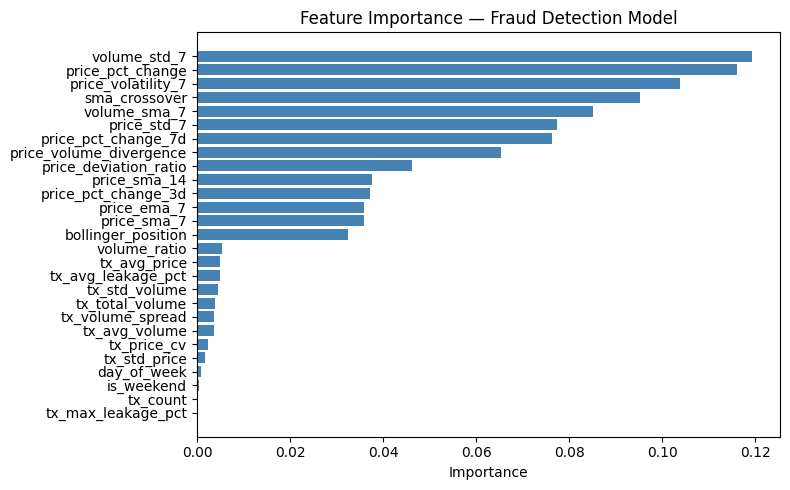

In [7]:
importance = model.get_feature_importance()
imp_df = pd.DataFrame({'feature': importance.keys(), 'importance': importance.values()})
imp_df = imp_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Fraud Detection Model')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. Confusion Matrix & ROC

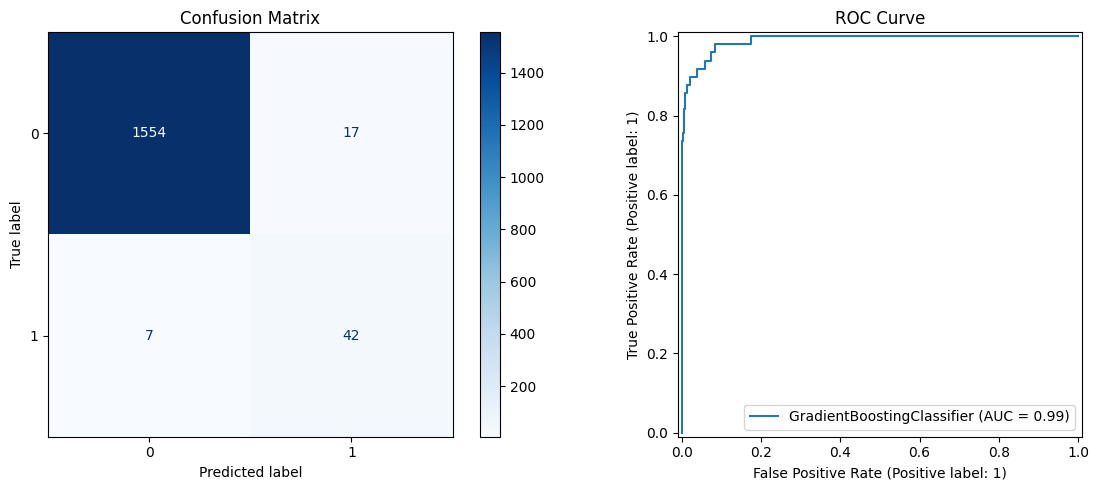

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = model.scaler.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(model.classifier, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_estimator(model.classifier, X_test_scaled, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

## 6. Predict Fraud Scores

In [9]:
scores = model.predict_fraud_score(X_test)
print(f'Fraud score range: {scores.min():.1f} - {scores.max():.1f}')
print(f'Mean: {scores.mean():.1f}, Median: {np.median(scores):.1f}')
print(f'High risk (>70): {(scores > 70).sum()} samples')

Fraud score range: 0.1 - 96.4
Mean: 9.4, Median: 5.3
High risk (>70): 32 samples


## 7. Save Model

In [10]:
import os
os.makedirs('../models', exist_ok=True)
model.save('../models/fraud_model.pkl')
print('Model saved!')

Model saved -> ../models/fraud_model.pkl
Model saved!
